In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
temperature    = pd.read_csv('temperature.csv',         index_col=0, parse_dates=True)
humidity       = pd.read_csv('humidity.csv',            index_col=0, parse_dates=True)
pressure       = pd.read_csv('pressure.csv',            index_col=0, parse_dates=True)
wind_speed     = pd.read_csv('wind_speed.csv',          index_col=0, parse_dates=True)
wind_direction = pd.read_csv('wind_direction.csv',      index_col=0, parse_dates=True)
weather_desc   = pd.read_csv('weather_description.csv', index_col=0, parse_dates=True)
city_attrs     = pd.read_csv('city_attributes.csv')

print("✅ All files loaded")

✅ All files loaded


In [3]:
print(temperature.shape)
print(temperature.head())

(45253, 36)
                      Vancouver    Portland  San Francisco     Seattle  \
datetime                                                                 
2012-10-01 12:00:00         NaN         NaN            NaN         NaN   
2012-10-01 13:00:00  284.630000  282.080000     289.480000  281.800000   
2012-10-01 14:00:00  284.629041  282.083252     289.474993  281.797217   
2012-10-01 15:00:00  284.626998  282.091866     289.460618  281.789833   
2012-10-01 16:00:00  284.624955  282.100481     289.446243  281.782449   

                     Los Angeles   San Diego   Las Vegas     Phoenix  \
datetime                                                               
2012-10-01 12:00:00          NaN         NaN         NaN         NaN   
2012-10-01 13:00:00   291.870000  291.530000  293.410000  296.600000   
2012-10-01 14:00:00   291.868186  291.533501  293.403141  296.608509   
2012-10-01 15:00:00   291.862844  291.543355  293.392177  296.631487   
2012-10-01 16:00:00   291.857503  291

In [4]:
for name, df in [('Temperature',        temperature),
                 ('Humidity',            humidity),
                 ('Pressure',            pressure),
                 ('Wind Speed',          wind_speed),
                 ('Wind Direction',      wind_direction),
                 ('Weather Description', weather_desc)]:
    print(name, ":", df.isnull().sum().sum(), "missing values")

Temperature : 8030 missing values
Humidity : 28651 missing values
Pressure : 16680 missing values
Wind Speed : 7993 missing values
Wind Direction : 7975 missing values
Weather Description : 7955 missing values


In [5]:
print("Avg Temperature:")
print((temperature.mean() - 273.15).round(1))

print("\nAvg Humidity:")
print(humidity.mean().round(1))

print("\nAvg Pressure:")
print(pressure.mean().round(1))

print("\nAvg Wind Speed:")
print(wind_speed.mean().round(1))

Avg Temperature:
Vancouver            10.7
Portland             11.8
San Francisco        15.0
Seattle              11.3
Los Angeles          17.7
San Diego            17.1
Las Vegas            19.3
Phoenix              22.3
Albuquerque          12.5
Denver                9.7
San Antonio          20.6
Dallas               19.2
Houston              21.1
Kansas City          13.5
Minneapolis           7.6
Saint Louis          13.5
Chicago              10.2
Nashville            15.4
Indianapolis         11.6
Atlanta              16.6
Detroit               9.8
Jacksonville         21.2
Charlotte            15.7
Miami                25.0
Pittsburgh           10.9
Toronto               8.8
Philadelphia         12.2
New York             12.3
Montreal              7.2
Boston               10.6
Beersheba            18.4
Tel Aviv District    21.4
Eilat                23.3
Haifa                22.1
Nahariyya            20.9
Jerusalem            20.0
dtype: float64

Avg Humidity:
Vancouver        

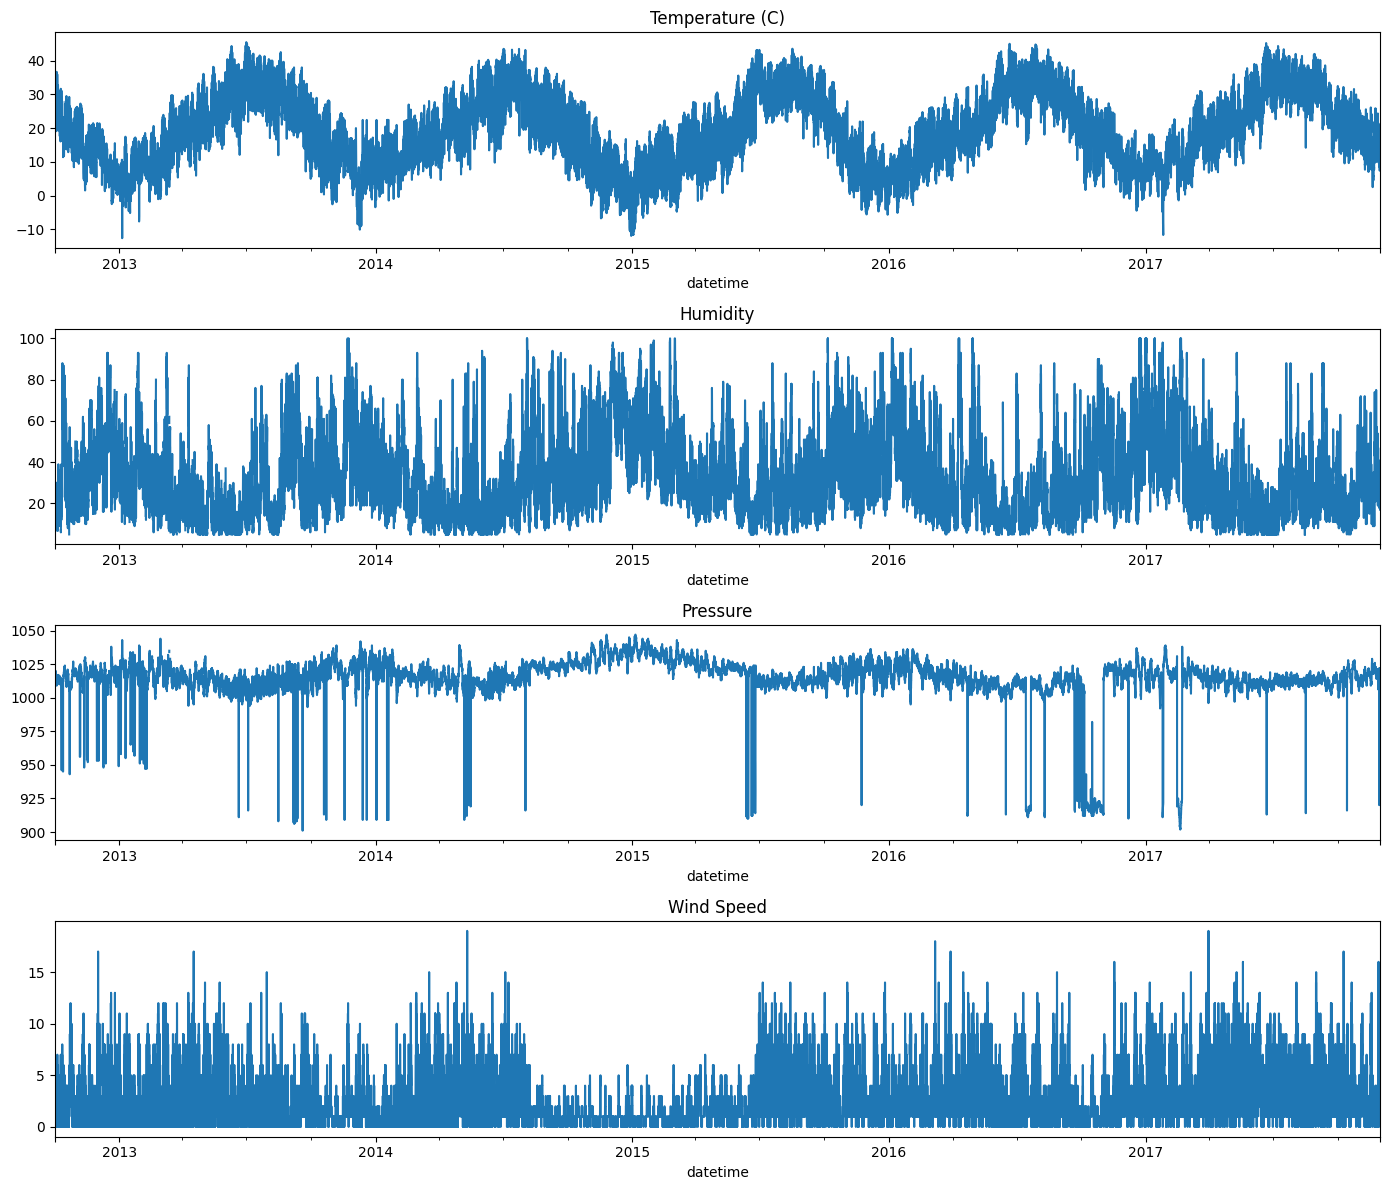

In [6]:
city = 'Las Vegas'

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

(temperature[city] - 273.15).plot(ax=axes[0], title='Temperature (C)')
humidity[city].plot(ax=axes[1],       title='Humidity')
pressure[city].plot(ax=axes[2],       title='Pressure')
wind_speed[city].plot(ax=axes[3],     title='Wind Speed')

plt.tight_layout()
plt.show()

In [7]:
temperature = temperature - 273.15

In [8]:
temperature = temperature.dropna()
humidity = humidity.dropna()
pressure = pressure.dropna()
wind_speed = wind_speed.dropna()

In [9]:
city = 'Las Vegas'

temp_city = temperature[city]
hum_city = humidity[city]
press_city = pressure[city]
wind_city = wind_speed[city]

In [10]:
weather_df = pd.concat([
    temp_city,
    hum_city,
    press_city,
    wind_city
], axis=1)

weather_df.columns = ['Temperature', 'Humidity', 'Pressure', 'WindSpeed']

print(weather_df.head())

                     Temperature  Humidity  Pressure  WindSpeed
datetime                                                       
2012-10-01 13:00:00    20.260000      22.0       NaN        0.0
2012-10-01 14:00:00    20.253141      21.0       NaN        0.0
2012-10-01 15:00:00    20.242177      21.0       NaN        0.0
2012-10-01 16:00:00    20.231213      21.0       NaN        0.0
2012-10-01 17:00:00    20.220249      21.0       NaN        0.0


In [11]:
weather_daily = weather_df.resample('D').mean()

In [12]:
# نتأكد من البيانات اليومية ونحذف أي قيم ناقصة
weather_daily = weather_daily.dropna()

print("Daily Weather Data:")
print(weather_daily.head())

print("\nShape:", weather_daily.shape)
print("\nMissing Values:")
print(weather_daily.isnull().sum())

Daily Weather Data:
            Temperature   Humidity  Pressure  WindSpeed
datetime                                               
2012-10-02    24.098385  17.933333    1019.0   1.375000
2012-10-03    27.541875  15.833333    1014.0   1.250000
2012-10-04    28.670000  16.666667    1011.0   1.958333
2012-10-06    26.000625  14.500000    1013.0   1.500000
2012-10-10    25.006667  14.500000     946.0   2.833333

Shape: (1716, 4)

Missing Values:
Temperature    0
Humidity       0
Pressure       0
WindSpeed      0
dtype: int64


In [13]:
# إحصائيات عامة للبيانات
print(weather_daily.describe())

       Temperature     Humidity     Pressure    WindSpeed
count  1716.000000  1716.000000  1716.000000  1716.000000
mean     19.686726    31.729113  1013.136939     2.444725
std       9.932086    17.505127    18.763801     1.579975
min      -5.028500     5.000000   903.458333     0.208333
25%      11.451875    17.915761  1009.833333     1.250000
50%      19.150766    27.708333  1014.833333     1.958333
75%      28.697964    41.687500  1021.500000     3.208333
max      39.488000    97.625000  1045.250000    10.041667


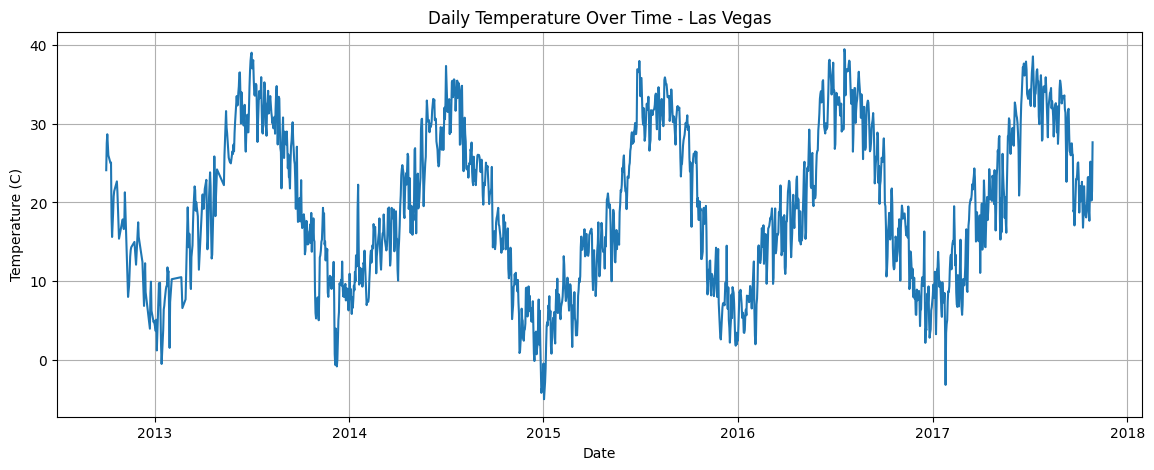

In [14]:
# رسم تغير الحرارة مع الوقت
plt.figure(figsize=(14,5))
plt.plot(weather_daily.index, weather_daily['Temperature'])
plt.title('Daily Temperature Over Time - Las Vegas')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.grid(True)
plt.show()

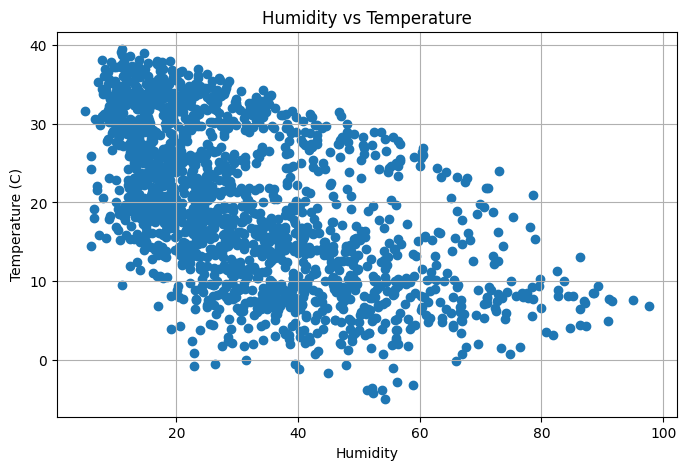

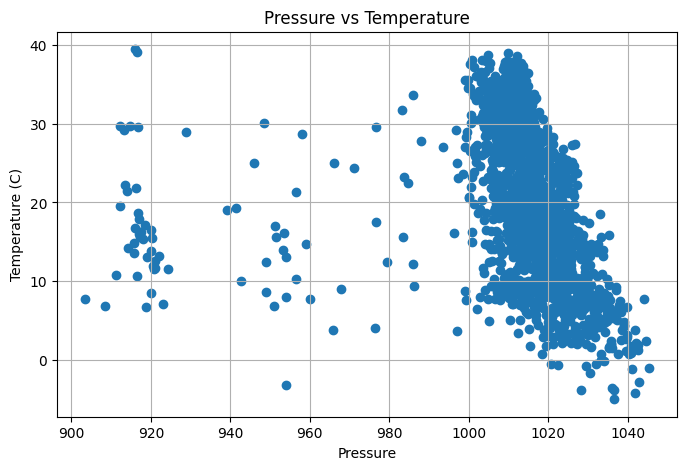

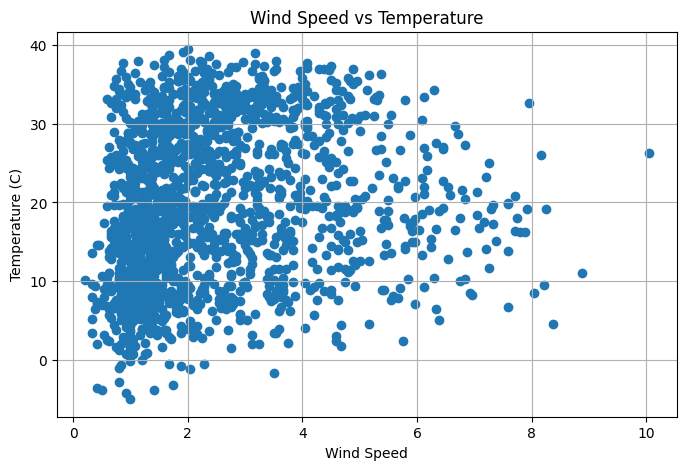

In [15]:
# رسم العلاقة بين الحرارة وباقي العوامل
plt.figure(figsize=(8,5))
plt.scatter(weather_daily['Humidity'], weather_daily['Temperature'])
plt.title('Humidity vs Temperature')
plt.xlabel('Humidity')
plt.ylabel('Temperature (C)')
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(weather_daily['Pressure'], weather_daily['Temperature'])
plt.title('Pressure vs Temperature')
plt.xlabel('Pressure')
plt.ylabel('Temperature (C)')
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(weather_daily['WindSpeed'], weather_daily['Temperature'])
plt.title('Wind Speed vs Temperature')
plt.xlabel('Wind Speed')
plt.ylabel('Temperature (C)')
plt.grid(True)
plt.show()

             Temperature  Humidity  Pressure  WindSpeed
Temperature     1.000000 -0.566396 -0.227148   0.166102
Humidity       -0.566396  1.000000  0.103623  -0.207388
Pressure       -0.227148  0.103623  1.000000  -0.079518
WindSpeed       0.166102 -0.207388 -0.079518   1.000000


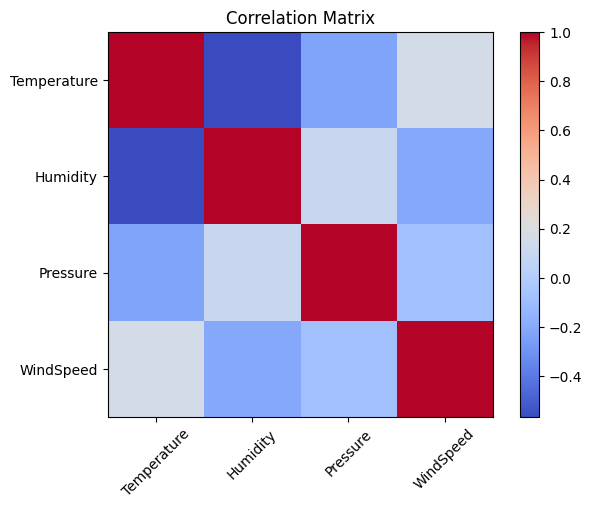

In [16]:
# Correlation Matrix
corr = weather_daily.corr()
print(corr)

plt.figure(figsize=(7,5))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

In [17]:
# تجهيز البيانات للمودل
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = weather_daily[['Humidity', 'Pressure', 'WindSpeed']]
y = weather_daily['Temperature']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1372, 3)
Testing data: (344, 3)


In [18]:
# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression Results
MAE: 6.63792691671403
RMSE: 7.885861635573823
R2 Score: 0.33023837804953926


In [19]:
# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results
MAE: 4.61814054555999
RMSE: 5.970477869233006
R2 Score: 0.616080528832653


In [20]:
# مقارنة بين القيم الحقيقية والمتوقعة
results = pd.DataFrame({
    'Actual Temperature': y_test.values,
    'Linear Regression Prediction': lr_pred,
    'Random Forest Prediction': rf_pred
})

print(results.head(10))

   Actual Temperature  Linear Regression Prediction  Random Forest Prediction
0           18.863917                     19.898448                 16.362733
1           12.515792                     14.423164                 12.608247
2           27.359813                     26.042548                 26.309145
3           27.788240                     27.943245                 29.773568
4            9.418000                     16.536766                 13.434302
5            6.867542                      6.872355                  5.931528
6           13.768333                     25.616647                 21.297365
7           22.836274                     24.063394                 29.445012
8           15.121250                     10.519283                 12.798095
9           21.844583                     22.723318                 21.603787


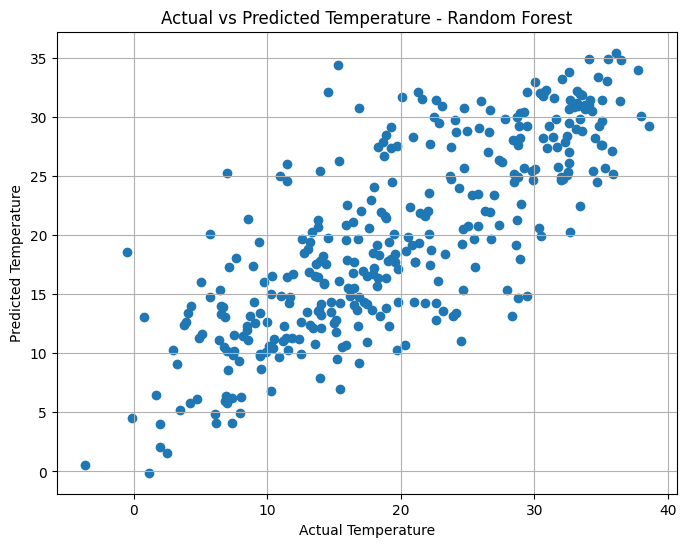

In [21]:
# رسم Actual vs Predicted للمودل الأفضل غالباً Random Forest
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred)
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs Predicted Temperature - Random Forest')
plt.grid(True)
plt.show()

In [22]:
# مقارنة أداء النماذج
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

print(model_comparison)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  6.637927  7.885862  0.330238
1      Random Forest  4.618141  5.970478  0.616081
